In [5]:
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import pyreadr
import yfinance  as yf
import numpy as np
import scipy.stats
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson,jarque_bera
# altri possibili test da consultare per heteroskedasticità e autocorrelazione sono:
from statsmodels.stats.diagnostic import het_goldfeldquandt, het_white, acorr_ljungbox #heteroskedasticità
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from math import sqrt
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.cluster.hierarchy import dendrogram
from sklearn.metrics import silhouette_samples, silhouette_score

In [4]:
!pip install plotly scikit-learn pandas pyreadr yfinance numpy scipy matplotlib seaborn statsmodels arch scikit-fuzzy --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.2/776.2 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 54.2 MB/s eta 0:00:00


IMPORT DEL DATASET FAMA-FRENCH

In [ ]:
import os

print("Directory corrente:", os.getcwd())
print("File presenti:", os.listdir())


Directory corrente: c:\Users\vince\Downloads\fama_french_analysis-main\fama_french_analysis-main
File presenti: ['companiesmarketcap.com - Largest insurance companies by market cap - Copia.csv', 'companiesmarketcap.com - Largest insurance companies by market cap.csv', 'F-F_Research_Data_Factors_daily.CSV', 'FamaFrenchproject.ipynb', 'FamaFrench_3Factors.RData', 'README.md']


In [ ]:
import pyreadr

file_path = r"C:\Users\vince\Downloads\fama_french_analysis-main\fama_french_analysis-main\FamaFrench_3Factors.RData"

# Legge il file .RData
result = pyreadr.read_r(file_path)

# Mostra gli oggetti contenuti nel file
print("Oggetti nel file:", result.keys())

# Prendi il dataset dei fattori (di solito si chiama così)
df = result["ff.factors"]

print(df.head())
print(df.info())


Oggetti nel file: odict_keys(['.Random.seed', 'ff.factors'])
                  Date      Rm     SMB     HML      RF
rownames                                              
1990-07-02  1990-07-02  0.0072 -0.0006 -0.0033  0.0003
1990-07-03  1990-07-03  0.0021  0.0007 -0.0015  0.0003
1990-07-04  1990-07-04  0.0065 -0.0017 -0.0017  0.0003
1990-07-05  1990-07-05 -0.0071  0.0029  0.0014  0.0003
1990-07-06  1990-07-06  0.0023 -0.0017  0.0002  0.0003
<class 'pandas.core.frame.DataFrame'>
Index: 8545 entries, 1990-07-02 to 2023-03-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    8545 non-null   object 
 1   Rm      8545 non-null   float64
 2   SMB     8545 non-null   float64
 3   HML     8545 non-null   float64
 4   RF      8545 non-null   float64
dtypes: float64(4), object(1)
memory usage: 400.5+ KB
None


GESTIONE DEL DATASET FAMA-FRENCH

In [ ]:
df = result["ff.factors"]
df.head()

# costruisco un metodo che calcola i rendimenti in eccesso

# def calcola_rendimenti(df,Rm,Rf):
#      df["Excess_return"] = Rm-Rf
#      return df

# df_2 = calcola_rendimenti(df,df["Rm"],df["RF"])

# df_2.head()


,Date,Rm,SMB,HML,RF
rownames,,,,,
1990-07-02,1990-07-02,0.0072,-0.0006,-0.0033,0.0003
1990-07-03,1990-07-03,0.0021,0.0007,-0.0015,0.0003
1990-07-04,1990-07-04,0.0065,-0.0017,-0.0017,0.0003
1990-07-05,1990-07-05,-0.0071,0.0029,0.0014,0.0003
1990-07-06,1990-07-06,0.0023,-0.0017,0.0002,0.0003


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])



In [ ]:
start_date = "2013-06-19"
end_date = "2023-06-19"

In [ ]:
type(df["Date"])

pandas.core.series.Series

In [ ]:
df2 = df[
    (df["Date"] >= pd.to_datetime(start_date)) &
    (df["Date"] <= pd.to_datetime(end_date))
]

In [ ]:
df2.head()

,Date,Rm,SMB,HML,RF
rownames,,,,,
2013-06-19,2013-06-19,-0.0101,0.0024,0.0010,0.0
2013-06-20,2013-06-20,-0.0273,0.0060,-0.0006,0.0
2013-06-21,2013-06-21,-0.0047,0.0007,-0.0024,0.0
2013-06-24,2013-06-24,-0.0136,0.0016,-0.0020,0.0
2013-06-25,2013-06-25,0.0071,-0.0062,0.0042,0.0


CHECK MISSING VALUE

In [ ]:
df2.isna().sum()

Date    0
Rm      0
SMB     0
HML     0
RF      0
dtype: int64

CALCOLO DEI RENDIMENTI SWISS RE DB

In [ ]:
ticker = "SREN.SW"
px = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False
)

px.head()


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SREN.SW,SREN.SW,SREN.SW,SREN.SW,SREN.SW,SREN.SW
Date,,,,,,
2013-06-19,31.378172,69.699997,70.099998,69.349998,69.599998,1095901
2013-06-20,30.635370,68.050003,69.500000,67.800003,69.050003,1398879
2013-06-21,30.410275,67.550003,69.000000,67.550003,67.699997,2352262
2013-06-24,30.027605,66.699997,67.849998,66.099998,67.250000,1506807
2013-06-25,30.815443,68.449997,68.750000,66.949997,67.099998,1614128


PROBLEMA: LE COLONNE SONO MULTIINDEX MENTRE L'INDICE QUI SONO LE DATE. PER POTER MERGARE CORRETTAMENTE I DUE DATASET E' NECESSARIO CREARE UNA STRUTTURA PER ENTRAMBI I DATASET CHE PERMETTA POI DI FARE IL MERGE

In [ ]:
px.columns
px.index

DatetimeIndex(['2013-06-19', '2013-06-20', '2013-06-21', '2013-06-24',
               '2013-06-25', '2013-06-26', '2013-06-27', '2013-06-28',
               '2013-07-01', '2013-07-02',
               ...
               '2023-06-05', '2023-06-06', '2023-06-07', '2023-06-08',
               '2023-06-09', '2023-06-12', '2023-06-13', '2023-06-14',
               '2023-06-15', '2023-06-16'],
              dtype='datetime64[ns]', name='Date', length=2512, freq=None)

In [ ]:
h0=[(4,"Hello"),(3,"Sorry")]
isinstance(h0, dict)

False

CORREZIONE DELL'INDICE COLONNA. Usiamo il metodo isinstance in quanto permette di capire il tipo di oggetto essendo le colonne del db swissre MultiIndex

In [ ]:
if isinstance(px.columns,pd.MultiIndex):
    px.columns = px.columns.get_level_values(0)

In [ ]:
px.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

ORA LE COLONNE APPAIONO CORRETTE

In [ ]:
px.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2013-06-19,31.378172,69.699997,70.099998,69.349998,69.599998,1095901
2013-06-20,30.635370,68.050003,69.500000,67.800003,69.050003,1398879
2013-06-21,30.410275,67.550003,69.000000,67.550003,67.699997,2352262
2013-06-24,30.027605,66.699997,67.849998,66.099998,67.250000,1506807
2013-06-25,30.815443,68.449997,68.750000,66.949997,67.099998,1614128


CALCOLO DEI LOG RETURN  ADJUSTED

In [ ]:
# facendo in questo modo otteniamo un oggetto di tipo Series. Una volta ottenuto va convertito in data frame con il metodo to_frame(name = "Nome della colonna")

swissre = np.log(px["Adj Close"]/ px["Adj Close"].shift(1))

swissre = swissre.dropna().to_frame(name="Log_Returns")

CHECK DEL TIPO:
Ritorna un pandas.core.frame.DataFrame

In [ ]:
swissre.head()
# type(swissre)

,Log_Returns
Date,
2013-06-20,-0.023957
2013-06-21,-0.007375
2013-06-24,-0.012663
2013-06-25,0.025899
2013-06-26,0.020247


LAVORIAMO ORA SULL'INDICE DATE PER PORTARLO COME COLONNA E MERGARLO CON L'ALTRO.
Prima di fare il merge è necessario eliminare la parte oraria e utilizziamo cosi il metodo .dt.normalize

In [ ]:
swissre = swissre.reset_index()

swissre["Date"] = pd.to_datetime(swissre["Date"]).dt.normalize()

In [ ]:
swissre.head()

,Date,Log_Returns
0,2013-06-20,-0.023957
1,2013-06-21,-0.007375
2,2013-06-24,-0.012663
3,2013-06-25,0.025899
4,2013-06-26,0.020247


DATASET MERGED

In [ ]:
merged_data = pd.merge(
    swissre,
    df2,
    on="Date",
    how="inner"
)


In [ ]:
merged_data.head()

,Date,Log_Returns,Rm,SMB,HML,RF
0,2013-06-20,-0.023957,-0.0273,0.0060,-0.0006,0.0
1,2013-06-21,-0.007375,-0.0047,0.0007,-0.0024,0.0
2,2013-06-24,-0.012663,-0.0136,0.0016,-0.0020,0.0
3,2013-06-25,0.025899,0.0071,-0.0062,0.0042,0.0
4,2013-06-26,0.020247,0.0071,-0.0118,0.0016,0.0


A questo punto andiamo a ridefinire l'indice delle date con il metodo set_index

In [ ]:
merged_data = merged_data.set_index("Date")

merged_data.head()



,Log_Returns,Rm,SMB,HML,RF
Date,,,,,
2013-06-20,-0.023957,-0.0273,0.0060,-0.0006,0.0
2013-06-21,-0.007375,-0.0047,0.0007,-0.0024,0.0
2013-06-24,-0.012663,-0.0136,0.0016,-0.0020,0.0
2013-06-25,0.025899,0.0071,-0.0062,0.0042,0.0
2013-06-26,0.020247,0.0071,-0.0118,0.0016,0.0


MERGED DATASET

In [ ]:
merged_data.head()

#DatetimeIndex
# merged_data.index

# merged_data.columns

,Log_Returns,Rm,SMB,HML,RF
Date,,,,,
2013-06-20,-0.023957,-0.0273,0.0060,-0.0006,0.0
2013-06-21,-0.007375,-0.0047,0.0007,-0.0024,0.0
2013-06-24,-0.012663,-0.0136,0.0016,-0.0020,0.0
2013-06-25,0.025899,0.0071,-0.0062,0.0042,0.0
2013-06-26,0.020247,0.0071,-0.0118,0.0016,0.0


A QUESTO PUNTO DEFINIAMO UN METODO PER CALCOLARE GLI EXCESS RETURN SIA DI SWISS RE SIA DI QUELLO DEL PORTAFOGLIO DI MERCATO

In [ ]:
def excess_return(asset_return,risk_free):
    return asset_return-risk_free

# creo una nuova colonna nel dataset merge con i rendimenti in eccesso di swiss re
merged_data["Swiss_Excess_Return"]=excess_return(asset_return=merged_data["Log_Returns"],risk_free=merged_data["RF"])

# stessa cosa con il rendimento di mercato

merged_data["Market_Return"] = excess_return(asset_return=merged_data["Rm"],risk_free=merged_data["RF"])

In [ ]:
merged_data["Market_Return"].shape
merged_data["Swiss_Excess_Return"].shape

(2461,)

In [ ]:
merged_data["Market_Return"].head()

merged_data["Swiss_Excess_Return"].head()

merged_data["Market_Return"].shape
merged_data["Swiss_Excess_Return"].shape



(2461,)

STATISTICHE DESCRITTIVE DEL DATASET

In [ ]:
merged_data.index


DatetimeIndex(['2013-06-20', '2013-06-21', '2013-06-24', '2013-06-25',
               '2013-06-26', '2013-06-27', '2013-06-28', '2013-07-01',
               '2013-07-02', '2013-07-03',
               ...
               '2023-03-20', '2023-03-21', '2023-03-22', '2023-03-23',
               '2023-03-24', '2023-03-27', '2023-03-28', '2023-03-29',
               '2023-03-30', '2023-03-31'],
              dtype='datetime64[ns]', name='Date', length=2461, freq=None)

In [ ]:
# Non ci sono valori mancanti nella serie

merged_data.isna().sum()

# Statistiche descrittive del dataset

merged_data[["Log_Returns","Rm"]].describe()

# andiamo a vedere la shape del nostro db.

merged_data.shape  # 2461 righe e 6 colonne



(2461, 7)

    CALCOLO DEGLI EXCESS RETURN  PER SWISS RE E PER QUELLI DI MERCATO
    

In [ ]:
def calcolo_rendimenti_eccesso(merged_data):
    return merged_data["Log_Returns"]- merged_data["Rm"]

PLOT DEI RENDIMENTI:

ANDIAMO A FARE UN'ANALISI GRAFICA DELLA DISTRIBUZIONE DEI LOG-RENDIMENTI E DEL RENDIMENTO DI MERCATO

In [ ]:
calcolo_corr = merged_data[["Rm","Log_Returns"]].corr()

print(calcolo_corr)

                   Rm  Log_Returns
Rm           1.000000     0.548081
Log_Returns  0.548081     1.000000


<Axes: >

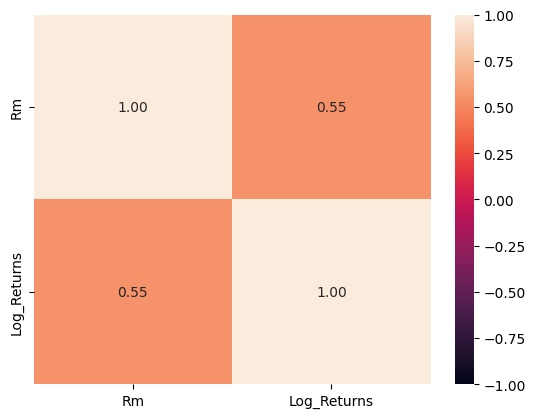

In [ ]:
sns.heatmap(calcolo_corr, vmin=-1,vmax=1,fmt=".2f",annot=True)
# annot parametro utile per stampare la correlazione fra gli asset quando sono cosi pochi. Essendo solo coppie di variabili possiamo passare direttamente allo scatterplot


In [ ]:
merged_data.head()

,Log_Returns,Rm,SMB,HML,RF,Swiss_Excess_Return,Market_Return
Date,,,,,,,
2013-06-20,-0.023957,-0.0273,0.0060,-0.0006,0.0,-0.023957,-0.0273
2013-06-21,-0.007375,-0.0047,0.0007,-0.0024,0.0,-0.007375,-0.0047
2013-06-24,-0.012663,-0.0136,0.0016,-0.0020,0.0,-0.012663,-0.0136
2013-06-25,0.025899,0.0071,-0.0062,0.0042,0.0,0.025899,0.0071
2013-06-26,0.020247,0.0071,-0.0118,0.0016,0.0,0.020247,0.0071


<Axes: >

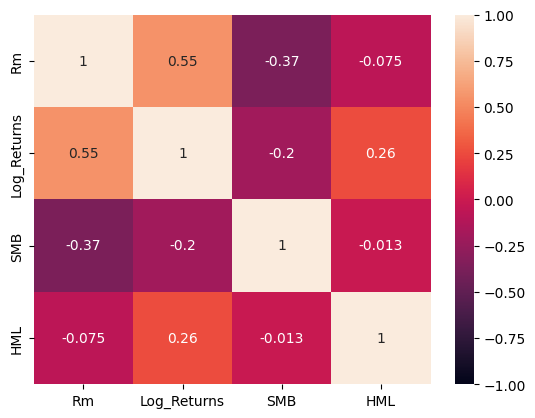

In [ ]:
calcolo_corr2 = merged_data[["Rm","Log_Returns","SMB","HML"]].corr()

sns.heatmap(calcolo_corr2, vmin=-1,vmax=1,annot=True)

INTERESSANTE NOTARE LA PRESENZA DI ALTISSIMI E BASSISSIMI RENDIMENTI DURANTE LA PANDEMIA. SI POTREBBE USARE UN MODELLO  HMM-GARCH PER CLASSIFICARE LA VOLATILITA' IN QUANTO I GARCH NASCONO CON L'IDEA DI MODELLARE VOLATILITY-CLUSTER.

<Axes: xlabel='Date'>

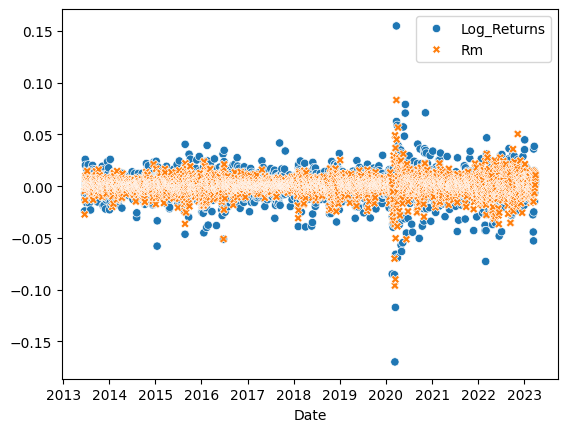

In [ ]:
sns.scatterplot(merged_data[["Log_Returns","Rm"]])

<Axes: xlabel='Rm', ylabel='Log_Returns'>

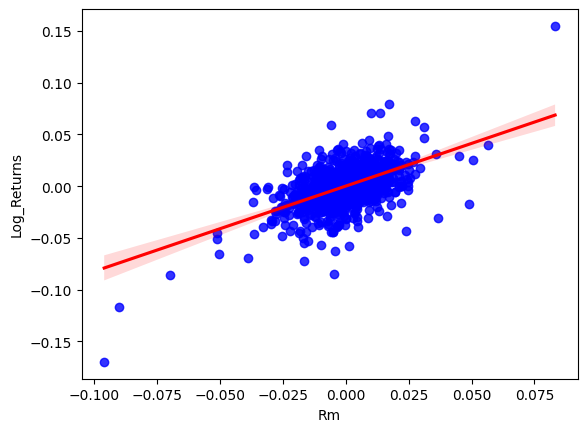

In [ ]:
sns.regplot(
    data=merged_data,
    x="Rm",
    y="Log_Returns",
    scatter_kws={"color": "blue"},
    line_kws={"color": "red"}
)


FIT DEL MODELLO considerando come covariata solo il rendimento di mercato

In [ ]:
X = merged_data["Market_Return"]
y = merged_data["Swiss_Excess_Return"]

X = sm.add_constant(X)

modello = sm.OLS(y,X)

result = modello.fit()

print(result.summary())

print(f"Parametri stimati: {result.params}")
print(f"Standar_Errors: {result.bse}")


                             OLS Regression Results                            
Dep. Variable:     Swiss_Excess_Return   R-squared:                       0.300
Model:                             OLS   Adj. R-squared:                  0.300
Method:                  Least Squares   F-statistic:                     1056.
Date:                 Sun, 11 Jan 2026   Prob (F-statistic):          4.91e-193
Time:                         17:23:37   Log-Likelihood:                 7462.8
No. Observations:                 2461   AIC:                        -1.492e+04
Df Residuals:                     2459   BIC:                        -1.491e+04
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          7.579e-05      0.000 

Dai risultati si evince che l' R-quadro Adjusted non è molto alto.

Andiamo a fittare un modello anche con altre variabili esplicative

In [ ]:
merged_data.columns

X_1 = merged_data[["Market_Return","SMB","HML"]]

y_1 = merged_data["Swiss_Excess_Return"]

X_1 = sm.add_constant(X_1)

modello_full = sm.OLS(y_1,X_1)

risultato_full = modello_full.fit()

print(risultato_full.summary())

                             OLS Regression Results                            
Dep. Variable:     Swiss_Excess_Return   R-squared:                       0.389
Model:                             OLS   Adj. R-squared:                  0.389
Method:                  Least Squares   F-statistic:                     522.4
Date:                 Sun, 11 Jan 2026   Prob (F-statistic):          1.48e-262
Time:                         17:23:37   Log-Likelihood:                 7630.3
No. Observations:                 2461   AIC:                        -1.525e+04
Df Residuals:                     2457   BIC:                        -1.523e+04
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0001      0.000 

Valutazione della presenza di multicollinearità attraverso il test VIF dovuto alla presenza di un cond. No. >100. Oppure valutare attraverso la radice quadrato del rapporto degli autovalori della matrice (XX^-1) ha un valore minore di 100.

Interpretazione del VIF:

1.   Valori => 5 multinearità problematica per il modello
2.   Valori (1-5) mutlinearità tollerabile



In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = merged_data[["Market_Return", "SMB", "HML"]]
X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i)
                 for i in range(X.shape[1])]

print(vif_df)

        variable       VIF
0          const  1.001320
1  Market_Return  1.166348
2            SMB  1.159948
3            HML  1.007650


OCCORE FARE DEI TEST STATISTICI PER CAPIRE SE LE IPOTESI SOTTOSTANTI IL MODELLO DI REGRESSIONE LINEARE SONO VERIFICATE.
In particolare, verranno condotti dei test su heteroschedasticità, autocorrelazione e test sulla normalità dei residui.
L'utilizzo di test diagnostici permette di capire se gli stimatori dei parametri beta ottenuti dal modello siano BLUE. (Best linear umbiesed estimator)

Autocorrelazione dei residui- DURBIN WATSON TEST


Il durbin watson test è un test statistico che permette di capire se c'è autocorrelazione tra i residui del modello stimato.
Se:
DW è approssimativamente 2 allora non c'è autocorrelazione
DW <2 autocorrelazione positiva
DW >2 autocorrelazione negativa

In [ ]:

dw = durbin_watson(result.resid)

print(dw)




1.869770231557222


AUTOCORRELAZIONE
Data una serie storica temporale come quella che stiamo analizzando, la funzione di autocorrelazione misura quanto l'elemento della serie Xt, abbia una relazione con un istante di tempo precedente X(t-h). L'analisi dell'andamento della funzione di correlazione al variare di questo h è di fondamentale importanza per stabilire la "memoria" della serie storica. In poche parole andiamo a vedere quanto di ciò che vediamo all'istante t risenta di cio che è successo a (t-h)

AUTOCORRELAZIONI GLOBALI

La funzione acf ritorna una tupla di array, in questo caso potrebbe essere utile scegliere un certo numero di " trading days " per vedere se ci sono correlazione con i valori ritardati dei residui. Questo ci potrebbe permettere di fittare dei modelli autoregressivi o di capire piu in generale meglio l'andamento dell' autocorrelazione. Si potrebbe sfruttare l'informazione sul numero di lag p da inserire per fittare una regressione ausiliaria e costruire una statistica test come nel caso di Godfey

In [ ]:
acf_prova = acf(risultato_full.resid, nlags = 10, qstat= True, fft=False)


Uno strumento utile per valutare se la serie è stazionaria potrebbe essere il correlogramma, questo rappresenta un grafico a barre che riporta i coefficienti di correlazione per ogni k della serie sull'asse delle ascisse. Affinchè non ci sia una forte relazione tra i periodi le barre dovrebbero stare entro le bande con un andamento variabile

<Figure size 1600x800 with 0 Axes>

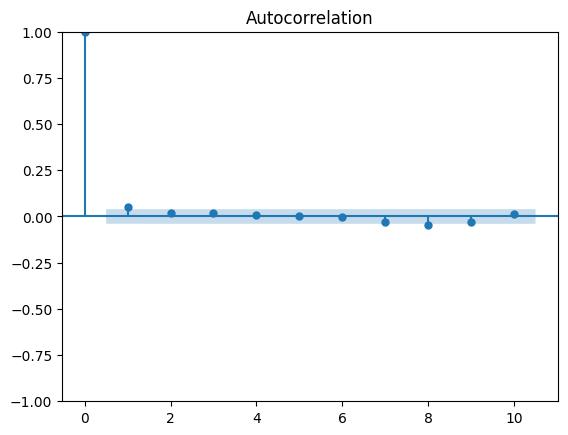

In [ ]:
plt.figure(figsize=(16,8))
plot_acf(risultato_full.resid, lags=10)
plt.show()

ANALISI DELLA NORMALITA'. Un aspetto importante da tenere in considerazione riguarda il fatto che nel 2020 ci sono stati degli spike dovuti alla pandemia. Questo fatto potrebbe comportare delle code piu pesanti della distribuzione normale. Si potrebbe usare una dummy variable con valore 1 se il periodo è 2020, 0 altrove. Si potrebbe poi rieseguire il test di jarque e bera per vedere se l'ipotesi di normalità possa essere accettata sotto H0.

In [ ]:
import pandas as pd

df.index = pd.to_datetime(df.index)

df["COVID"] = (
    (df.index >= "2020-02-24") &
    (df.index <= "2020-06-30")
).astype(int)


Introduciamo la variabile dummy per tenere in considerazione l'effetto del covid nel modello di regressione

In [ ]:
import datetime
start_date = datetime.datetime(2013,6,19)
end_date = datetime.datetime(2023,6,19)

In [ ]:
merged_data["COVID"] = (
    (merged_data.index >= "2020-02-24") &
    (merged_data.index <= "2020-06-30")
).astype(int)


Controllo che la colonna che include la dummy variable sia stata creata correttamente


In [ ]:
merged_data.columns.view()


Index(['Log_Returns', 'Rm', 'SMB', 'HML', 'RF', 'Swiss_Excess_Return',
       'Market_Return', 'COVID'],
      dtype='object')

In [ ]:
merged_data["COVID"].isna().sum()


np.int64(0)

In [ ]:
(df["COVID"]==1).sum()

np.int64(92)

L'analisi di regressione aggiungendo la variabile Covid come regressore ha evidenziato, aggiungendo la dummy Covid, il modello non ha aumentato la capacità di spiegare i rendimenti;

In [ ]:
merged_data.columns

X_2 = merged_data[["Market_Return","SMB","HML","COVID"]]

y_2 = merged_data["Swiss_Excess_Return"]

X_2 = sm.add_constant(X_2)

modello_full = sm.OLS(y_2,X_2)
risultato_full_1 = modello_full.fit()

print(risultato_full_1.summary())

                             OLS Regression Results                            
Dep. Variable:     Swiss_Excess_Return   R-squared:                       0.390
Model:                             OLS   Adj. R-squared:                  0.389
Method:                  Least Squares   F-statistic:                     392.3
Date:                 Sun, 11 Jan 2026   Prob (F-statistic):          1.65e-261
Time:                         17:23:38   Log-Likelihood:                 7631.1
No. Observations:                 2461   AIC:                        -1.525e+04
Df Residuals:                     2456   BIC:                        -1.522e+04
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0002      0.000 

Fitting del modello OLS con la presenza del termine d'interazione.
L'aggiunta nel modello anche del termine di interazione ci permette di valutare se come il rendimento di mercato impatti il portafoglio nel periodo Covid.


In [ ]:
print(risultato_full.summary())
print("\n" + "="*80 + "\n")  # separatore
print(risultato_full_1.summary())


                             OLS Regression Results                            
Dep. Variable:     Swiss_Excess_Return   R-squared:                       0.389
Model:                             OLS   Adj. R-squared:                  0.389
Method:                  Least Squares   F-statistic:                     522.4
Date:                 Sun, 11 Jan 2026   Prob (F-statistic):          1.48e-262
Time:                         17:23:38   Log-Likelihood:                 7630.3
No. Observations:                 2461   AIC:                        -1.525e+04
Df Residuals:                     2457   BIC:                        -1.523e+04
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0001      0.000 

Il modello OLS evidenzia come il termine d'interazione sia statisticamente significativo, il portafoglio quindi diventa più sensibile all'eccesso di rendimento del mercato durante il periodo Covid. L'R^2 aumenta maggiormente rispetto all'introduzione della sola variabile dummy.


In [ ]:
#Calcolo del termine di interazione Covid x (Rm-Rf)
merged_data["Covid_Market"] = merged_data["Market_Return"] * merged_data["COVID"]

merged_data.columns

X_3 = merged_data[["Market_Return","SMB","HML","COVID","Covid_Market"]]

y_3 = merged_data["Swiss_Excess_Return"]

X_3 = sm.add_constant(X_3)

modello_full = sm.OLS(y_3,X_3)
risultato_full_2 = modello_full.fit()

print(risultato_full_2.summary())

                             OLS Regression Results                            
Dep. Variable:     Swiss_Excess_Return   R-squared:                       0.398
Model:                             OLS   Adj. R-squared:                  0.396
Method:                  Least Squares   F-statistic:                     324.1
Date:                 Sun, 11 Jan 2026   Prob (F-statistic):          4.89e-267
Time:                         17:23:38   Log-Likelihood:                 7646.9
No. Observations:                 2461   AIC:                        -1.528e+04
Df Residuals:                     2455   BIC:                        -1.525e+04
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0002      0.000 

Jarque bera con dummy variable e termine d'interazione

In [ ]:
output = jarque_bera(risultato_full_2.resid)
print(output)


(np.float64(4015.3744264621932), np.float64(0.0), np.float64(-0.40364929119425114), np.float64(9.205379567072642))


In [ ]:

# Scrivo un metodo che prende in input il p-value e alpha e ritorna il risultato del test

def  test_statistico(alpha,p_value):
    if alpha > p_value:
        print("Rigettiamo H0")
    else:
        print("Accettiamo H0 in quanto il p-value è maggiore di alpha")


test_statistico(alpha=0.05,p_value=output[1])



Rigettiamo H0


In [ ]:
risultato_full_2.params

const            0.000198
Market_Return    0.777029
SMB              0.081705
HML              0.689642
COVID           -0.001606
Covid_Market     0.295386
dtype: float64

Passaggi da verificare:
- Fitting modello OLS e osservare non ci sia multicollinearità elevata
- Valutazione omeoschedasticità degli errori attraverso la valutazione del F-statistic ed LM-statistic    (H0 errori omeoschedastici)
- Presenza di eteroschedasticità -> soluzione: mantenere i coefficienti OLS (non distorti)
e utilizzare gli errori standard robusti o utilizzare un modello pesato.


In [ ]:
# Valutiamo l'eteroschedasticità con il test di Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

residui = risultato_full_2.resid
X_bp   = risultato_full_2.model.exog   # stessa X usata nel fit

bp_test = het_breuschpagan(residui, X_bp, robust=False)
lm_stat, lm_pvalue, f_stat, f_pvalue = bp_test
print("LM stat:", lm_stat, "LM p:", lm_pvalue)
print("F stat:", f_stat, "F p:", f_pvalue)


LM stat: 799.0869135913672 LM p: 1.82314289791265e-170
F stat: 42.19909407149718 F p: 8.130633367742134e-42


In [ ]:
# Estendiamo il test di Breusch-Pagan includendo termini non lineari e interazioni
Z = pd.DataFrame({
    "const": 1.0,
    "Market": merged_data["Market_Return"],
    "SMB": merged_data["SMB"],
    "HML": merged_data["HML"],
    "COVID": merged_data["COVID"],
    "Covid_Market": merged_data["Covid_Market"],
    # termini non lineari / interazioni aggiuntive per la varianza
    "Market2": merged_data["Market_Return"]**2,
    "HML2": merged_data["HML"]**2,
    "Market_HML": merged_data["Market_Return"] * merged_data["HML"],
})

from statsmodels.stats.diagnostic import het_breuschpagan

residui = risultato_full_2.resid
bp_test_ext = het_breuschpagan(residui, Z.values)

lm_stat, lm_pvalue, f_stat, f_pvalue = bp_test_ext
print("LM stat:", lm_stat, "LM p:", lm_pvalue)
print("F stat:", f_stat, "F p:", f_pvalue)


LM stat: 345.71308981017586 LM p: 7.444260082122807e-70
F stat: 50.09299755809961 F p: 2.1810740801378304e-75


Il test ha come risultato il rifiuto di H0 (omeoschedasticità degli errori), è presente quind iun eteroschedasticità dei residui dovuta all'effetto odei diversi regressori fittati dal modello OLS

In [ ]:
X_bp.view()

array([[ 1.00e+00, -2.73e-02,  6.00e-03, -6.00e-04,  0.00e+00, -0.00e+00],
       [ 1.00e+00, -4.70e-03,  7.00e-04, -2.40e-03,  0.00e+00, -0.00e+00],
       [ 1.00e+00, -1.36e-02,  1.60e-03, -2.00e-03,  0.00e+00, -0.00e+00],
       ...,
       [ 1.00e+00,  1.18e-02, -4.10e-03, -2.90e-03,  0.00e+00,  0.00e+00],
       [ 1.00e+00,  7.90e-03,  1.00e-04, -4.00e-03,  0.00e+00,  0.00e+00],
       [ 1.00e+00,  1.05e-02, -1.10e-03, -4.70e-03,  0.00e+00,  0.00e+00]],
      shape=(2461, 6))

Controllare visivamente quando i rendimenti si discostano da 3 la varianza

In [ ]:
residui = risultato_full.resid
outliers = np.abs(residui) > 3*residui.std()  # spike oltre 3 deviazioni standard
print(merged_data.index[outliers])


DatetimeIndex(['2015-01-15', '2015-01-16', '2015-08-25', '2016-04-29',
               '2017-09-11', '2017-10-26', '2018-02-06', '2018-02-08',
               '2018-04-04', '2019-05-03', '2019-08-30', '2020-02-20',
               '2020-03-12', '2020-03-13', '2020-03-16', '2020-03-17',
               '2020-03-24', '2020-03-31', '2020-04-08', '2020-04-20',
               '2020-04-22', '2020-04-30', '2020-05-04', '2020-06-02',
               '2020-06-03', '2020-07-23', '2020-09-09', '2020-10-15',
               '2020-10-30', '2021-04-30', '2021-10-29', '2022-02-25',
               '2022-03-01', '2022-03-04', '2022-08-31', '2022-09-02',
               '2022-09-28', '2022-10-14', '2022-10-28', '2022-11-09',
               '2023-01-03', '2023-01-04'],
              dtype='datetime64[ns]', name='Date', freq=None)


Sembra che dall'analisi della cdf empirica ci siano degli outlier

<Axes: ylabel='Count'>

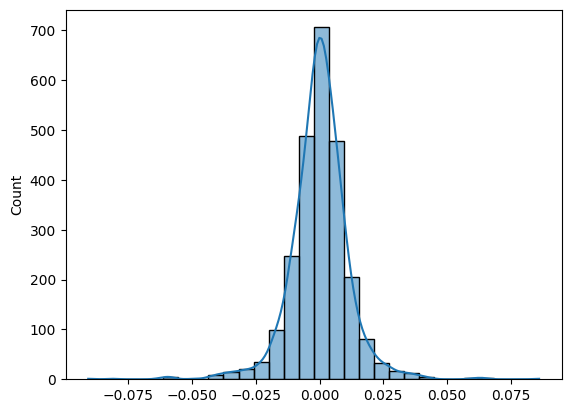

In [ ]:
result.resid.mean()

sns.histplot(result.resid, kde = True, bins = 30)

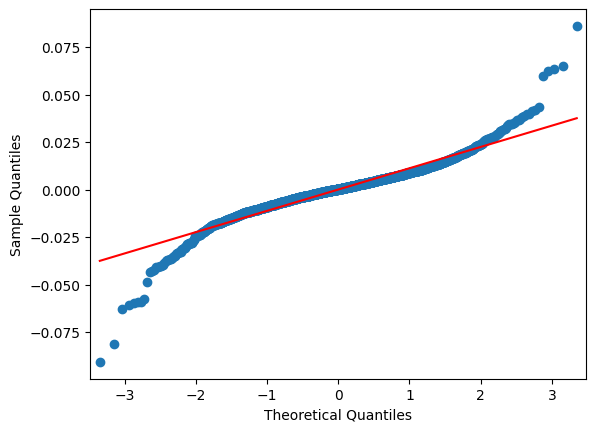

In [ ]:
sm.qqplot(result.resid, line ="r")
plt.show()


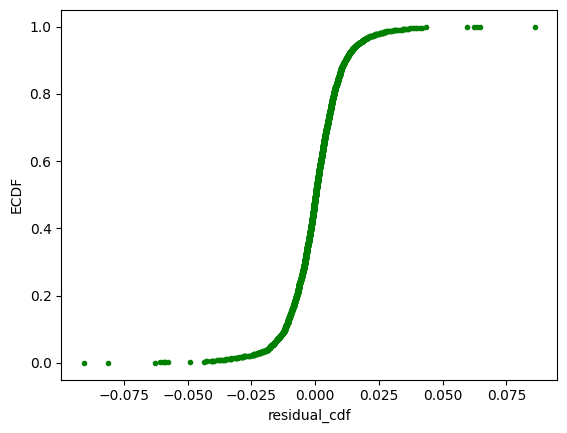

In [ ]:
resid_sorted = np.sort(result.resid.values)

n = len(resid_sorted)
p_s = np.linspace(0.5/n, 1 - 0.5/n, n)

plt.plot(resid_sorted, p_s, 'g.')
plt.xlabel("residual_cdf")
plt.ylabel("ECDF")
plt.show()


Jarque bera test è un test in cui si testano due ipotesi congiuntamente. Sotto l'ipotesi nulla la simmetria è zero mentre la kurtosi deve essere 3. Questo per le proprietà della funzione di densità della normale. Fissato l'alpha possiamo confrontarlo con il p-value. Tanto piu il p-value è piccolo tanto piu andiamo a rifiutare l'ipotesi di normalità. Tuttavia, è possibile sempre sfruttare il teorema del limite centrale con un n sufficientemente grande possiamo accettare l'approssimazione dei residui alla normale standard. (Quanto deve essere grande n?)

Leggendo la documentazione il metodo jarque_bera ritorna un array con i seguenti output:
- JB che indica la statistica test
- JBpv che indica il pvalue del test statistico
- l'asimmetria della distribuzione
- la kurotis della distribuzione




In [ ]:
output = jarque_bera(result.resid)
print(output)

# Scrivo un metodo che prende in input il p-value e alpha e ritorna il risultato del test

def  test_statistico(alpha,p_value):
    if alpha > p_value:
        print("Rigettiamo H0")
    else:
        print("Accettiamo H0 in quanto il p-value è maggiore di alpha")


test_statistico(alpha=0.05,p_value=output[1])



(np.float64(5470.0838682879985), np.float64(0.0), np.float64(-0.33115011281025364), np.float64(10.273674816957541))
Rigettiamo H0


I parametri disp e update_freq. Disp controlla cosa viene stampato mentre viene fatta la stima mentre update freq in fit, regola il numero di iterazioni nella stima dei parametri della log likelihood. Questo perchè per ipotesi, nel modello specificato i rendimenti in eccesso di swiss sono distribuiti come una normale standard.

Fit dei modelli Garch (1,1) e GJR (1,1,1) con distribuzione normale degli errori.


In [ ]:
y_garch = merged_data["Swiss_Excess_Return"]

y_garch.head()


# fit garch(1,1)

spec = arch_model(y_garch,
           mean="constant",
           vol="GARCH",
           p=1,
           q=1,
           dist="normal",
           rescale=False)

garch_mod = spec.fit()

print(garch_mod.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 63134284.70456031
Iteration:      2,   Func. Count:     19,   Neg. LLF: 2.6089506428186007e+23
Iteration:      3,   Func. Count:     34,   Neg. LLF: 1.1365141592915695e+18
Iteration:      4,   Func. Count:     47,   Neg. LLF: 1.2256763567438915e+18
Iteration:      5,   Func. Count:     62,   Neg. LLF: 156501418168776.34
Iteration:      6,   Func. Count:     76,   Neg. LLF: -7445.433705192259
Optimization terminated successfully    (Exit mode 0)
            Current function value: -7445.433701738275
            Iterations: 10
            Function evaluations: 76
            Gradient evaluations: 6
                      Constant Mean - GARCH Model Results                      
Dep. Variable:     Swiss_Excess_Return   R-squared:                       0.000
Mean Model:              Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       GARCH   Log-Likelihood:                7445.43
Distribution:         

In [ ]:
y_garch_t = merged_data["Swiss_Excess_Return"]

y_garch_t.head()


# fit garch(1,1)

spec = arch_model(y_garch_t,
           mean="constant",
           vol="GARCH",
           p=1,
           q=1,
           dist="normale",
           rescale=True)

garch_mod_t = spec.fit()

print(garch_mod_t.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 39507.39135051082
Iteration:      2,   Func. Count:     17,   Neg. LLF: 49205.399954181456
Iteration:      3,   Func. Count:     25,   Neg. LLF: 6654.725317062297
Iteration:      4,   Func. Count:     34,   Neg. LLF: 6414.589402265198
Iteration:      5,   Func. Count:     42,   Neg. LLF: 5624.671362707686
Iteration:      6,   Func. Count:     49,   Neg. LLF: 3771.1463490968886
Iteration:      7,   Func. Count:     57,   Neg. LLF: 3733.82213844331
Iteration:      8,   Func. Count:     63,   Neg. LLF: 3733.802591775269
Iteration:      9,   Func. Count:     69,   Neg. LLF: 3733.8014776213618
Iteration:     10,   Func. Count:     75,   Neg. LLF: 3733.801120821542
Iteration:     11,   Func. Count:     81,   Neg. LLF: 3733.801101487078
Iteration:     12,   Func. Count:     87,   Neg. LLF: 3733.801100414156
Iteration:     13,   Func. Count:     92,   Neg. LLF: 3733.801100414157
Optimization terminated successfully    (Exit mode 0)
        

In [ ]:
y_garch_t_1 = merged_data["Swiss_Excess_Return"]
y_garch_t_mean= y_garch_t.mean()
y_garch_t_sd= y_garch_t.std()
y_garch_t1 = (y_garch_t - y_garch_t_mean)/ y_garch_t_sd
print(f"Y_standard:{y_garch_t1}")

Y_standard:Date
2013-06-20   -1.741901
2013-06-21   -0.552879
2013-06-24   -0.932095
2013-06-25    1.832940
2013-06-26    1.427664
                ...   
2023-03-27    0.872993
2023-03-28    0.273190
2023-03-29    0.657794
2023-03-30    0.130744
2023-03-31    0.329274
Name: Swiss_Excess_Return, Length: 2461, dtype: float64


Modellazione degli errori attraverso i modelli Garch (1,1) GJR (1,1,1) con distribuzione degli errori t di student.

In [ ]:

# fit garch(1,1)

spec_1 = arch_model(y_garch_t1,
           mean="constant",
           vol="GARCH",
           p=1,
           q=1,
           dist="t",
           rescale=False)

garch_mod_t_1 = spec_1.fit()

print(garch_mod_t.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 43682.43280560442
Iteration:      2,   Func. Count:     18,   Neg. LLF: 44069.43974127588
Iteration:      3,   Func. Count:     27,   Neg. LLF: 5543.1293127788795
Iteration:      4,   Func. Count:     36,   Neg. LLF: 5640.365892149221
Iteration:      5,   Func. Count:     44,   Neg. LLF: 4891.882831449567
Iteration:      6,   Func. Count:     51,   Neg. LLF: 2915.207601349358
Iteration:      7,   Func. Count:     57,   Neg. LLF: 2915.1880423220155
Iteration:      8,   Func. Count:     63,   Neg. LLF: 2915.1869988474305
Iteration:      9,   Func. Count:     69,   Neg. LLF: 2915.186799941829
Iteration:     10,   Func. Count:     75,   Neg. LLF: 2915.1867990912506
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2915.1867990912506
            Iterations: 10
            Function evaluations: 75
            Gradient evaluations: 10
                        Constant Mean - GARCH Model Results       

In [ ]:
#AIC
garch_mod_t_1.aic
# BIC
garch_mod_t_1.bic

np.float64(5869.415213434457)

In [ ]:
from arch import arch_model

y_garch_t_1 = merged_data["Swiss_Excess_Return"]

# Specifica GJR-GARCH(1,1) con Student-t
spec_gjr = arch_model(
    y_garch_t_1,
    mean="constant",
    vol="GARCH",
    p=1,
    o=1,  # termine asimmetrico
    q=1,
    dist="t",
    rescale=False
)

# Fit
gjr_mod = spec_gjr.fit(update_freq=5, disp='off')
# Summary
print(gjr_mod.summary())


                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:          Swiss_Excess_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:                5285.58
Distribution:      Standardized Student's t   AIC:                          -10559.2
Method:                  Maximum Likelihood   BIC:                          -10524.3
                                              No. Observations:                 2461
Date:                      Sun, Jan 11 2026   Df Residuals:                     2460
Time:                              17:23:41   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

In [ ]:
from scipy.optimize import minimize

# Metodi disponibili in scipy.optimize.minimize
print(minimize.__doc__.split('method :')[1].split('\n')[0])


 str or callable, optional


In [ ]:
y_garch_n_3 = merged_data["Swiss_Excess_Return"]

# Specifica GJR-GARCH(1,1) con Student-t
spec_gjr = arch_model(
    y_garch_n_3,
    mean="constant",
    vol="GARCH",
    p=1,
    o=1,  # termine asimmetrico
    q=1,
    dist="normal",
    rescale=False
)

# Fit
gjr_mod_1 = spec_gjr.fit(update_freq=5, disp='final')

# Summary
print(gjr_mod_1.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: -7454.675702691811
            Iterations: 8
            Function evaluations: 50
            Gradient evaluations: 4
                    Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:     Swiss_Excess_Return   R-squared:                       0.000
Mean Model:              Constant Mean   Adj. R-squared:                  0.000
Vol Model:                   GJR-GARCH   Log-Likelihood:                7454.68
Distribution:                   Normal   AIC:                          -14899.4
Method:             Maximum Likelihood   BIC:                          -14870.3
                                         No. Observations:                 2461
Date:                 Sun, Jan 11 2026   Df Residuals:                     2460
Time:                         17:23:41   Df Model:                            1
                                 Mean Model                             

In [ ]:
y_garch_t = merged_data["Swiss_Excess_Return"]

y_garch_t.head()


# fit garch(1,1)

spec = arch_model(y_garch_t,
           mean="constant",
           vol="GARCH",
           p=1,
           q=1,
           dist="t",
           rescale=True)

garch_mod_t = spec.fit()

print(garch_mod_t.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 39507.39135051082
Iteration:      2,   Func. Count:     17,   Neg. LLF: 49205.399954181456
Iteration:      3,   Func. Count:     25,   Neg. LLF: 6654.725317062297
Iteration:      4,   Func. Count:     34,   Neg. LLF: 6414.589402265198
Iteration:      5,   Func. Count:     42,   Neg. LLF: 5624.671362707686
Iteration:      6,   Func. Count:     49,   Neg. LLF: 3771.1463490968886
Iteration:      7,   Func. Count:     57,   Neg. LLF: 3733.82213844331
Iteration:      8,   Func. Count:     63,   Neg. LLF: 3733.802591775269
Iteration:      9,   Func. Count:     69,   Neg. LLF: 3733.8014776213618
Iteration:     10,   Func. Count:     75,   Neg. LLF: 3733.801120821542
Iteration:     11,   Func. Count:     81,   Neg. LLF: 3733.801101487078
Iteration:     12,   Func. Count:     87,   Neg. LLF: 3733.801100414156
Iteration:     13,   Func. Count:     92,   Neg. LLF: 3733.801100414157
Optimization terminated successfully    (Exit mode 0)
        

In [ ]:
omega_t=garch_mod_t_1.params["omega"]
alpha_t=garch_mod_t_1.params["alpha[1]"]
beta_t=garch_mod_t_1.params["beta[1]"]
garch_mod_t_1.resid[1]






C:\Users\vince\AppData\Local\Temp\ipykernel_19068\701219165.py:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



np.float64(-0.5938573224385715)

In [ ]:
len(garch_mod_t_1.resid)


2461

In [ ]:
len(garch_mod_t_1.conditional_volatility)

2461

In [ ]:
print(garch_mod_t_1._volatility)

[0.92774036 1.07118756 1.02332176 ... 1.36361138 1.28547175 1.19678687]


In [ ]:
merged_vol_res=pd.DataFrame({
    "Volatility": garch_mod_t_1.conditional_volatility,
    "Residuals": garch_mod_t_1.resid

})

In [ ]:
merged_vol_res.head()

,Volatility,Residuals
Date,,
2013-06-20,0.927740,-1.782879
2013-06-21,1.071188,-0.593857
2013-06-24,1.023322,-0.973074
2013-06-25,1.017096,1.791962
2013-06-26,1.139423,1.386686


In [ ]:
sigma_1= omega_t/(1-alpha_t-beta_t)
print(f"Long-Run Variance: {sigma_1}")


Long-Run Variance: 1.0310193761563775


In [ ]:
sigma_2=omega_t+alpha_t*(merged_vol_res["Residuals"][0])**2+beta_t*(merged_vol_res["Volatility"][0])**2
print(f"One-step ahead Variance: {sqrt(sigma_2)}")

One-step ahead Variance: 1.071187558074135


C:\Users\vince\AppData\Local\Temp\ipykernel_19068\3866343457.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [ ]:
merged_vol_res["Volatility"]["2013-06-20"]

np.float64(0.9277403627523013)

In [ ]:
y_garch_t.mean()


np.float64(0.00033595239993371704)

Plot della varianza condizionata del modello Garch(1,1)

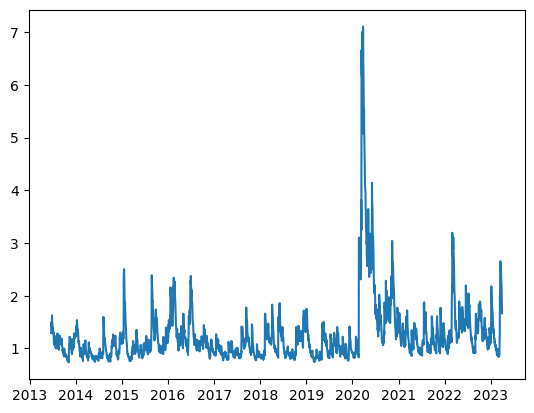

In [ ]:
plt.plot(garch_mod_t.conditional_volatility)

Plot dei residui del modello Garch(1,1) con distribuzione Student-t.

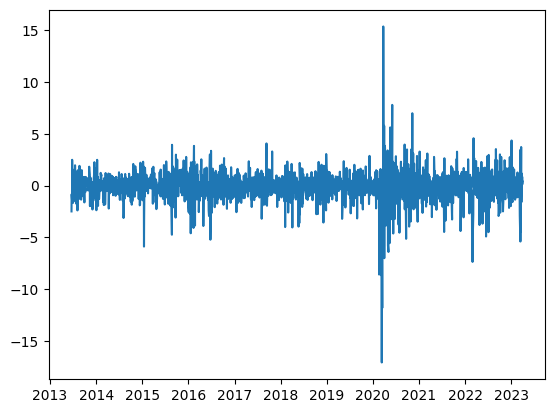

In [ ]:
plt.plot(garch_mod_t.resid)

In [ ]:
garch_mod_t.params

mu          0.090736
omega       0.066981
alpha[1]    0.121242
beta[1]     0.845357
nu          4.368017
Name: params, dtype: float64

In [ ]:
merged_data.tail()

,Log_Returns,Rm,SMB,HML,RF,Swiss_Excess_Return,Market_Return,COVID,Covid_Market
Date,,,,,,,,,
2023-03-27,0.012711,0.0049,-0.0011,0.0088,0.0002,0.012511,0.0047,0,0.0
2023-03-28,0.004346,0.0013,-0.0006,0.0073,0.0002,0.004146,0.0011,0,0.0
2023-03-29,0.009710,0.0120,-0.0041,-0.0029,0.0002,0.009510,0.0118,0,0.0
2023-03-30,0.002359,0.0081,0.0001,-0.0040,0.0002,0.002159,0.0079,0,0.0
2023-03-31,0.005128,0.0107,-0.0011,-0.0047,0.0002,0.004928,0.0105,0,0.0


In [ ]:
garch_forecast = garch_mod.forecast(horizon=2)

print(garch_forecast.variance)



                 h.1       h.2
Date                          
2023-03-31  0.000283  0.000282


Print dei parametri stimati dal modello garch e visualizzazione della varianza di lungo periodo.

In [ ]:

print(f"omega_stimato: {garch_mod.params["omega"]}")
print(f"alpha: {garch_mod.params["alpha[1]"]}")
print(f" beta: {garch_mod.params["beta[1]"]}")

# ritornano 3 float
omega = garch_mod.params["omega"]
alpha = garch_mod.params["alpha[1]"]
beta = garch_mod.params["beta[1]"]

omega_stimato: 3.888538856828068e-06
alpha: 0.10000000695104638
 beta: 0.8799999953059583


In [ ]:
long_run_variance = omega/(1-alpha-beta)
print(long_run_variance)

long_run_volatility = print(sqrt(long_run_variance))

0.00019442696478253184
0.013943706995721469


Download di 30 titoli a maggior capitalizzazione facente parte del mercato azionario americano e creazione della funzione per ottenere i log rendimenti.

In [67]:
symbols=[# Information Technology (6)
    "AAPL", "MSFT", "NVDA", "AMD", "INTC", "ADBE",
    # Financials (4)
    "JPM", "BAC", "GS", "WFC",
    # Industrials (5)
    "CAT", "BA", "DE", "GE", "HON",
    # Consumer Discretionary (4)
    "TSLA", "AMZN", "HD", "MCD",
    # Healthcare (3)
    "JNJ", "PFE", "MRK",
    # Energy (3)
    "XOM", "CVX", "SLB",
    # Communication Services (5)
    "GOOGL", "META", "NFLX", "T", "VZ"]
start_date = "2013-06-19"
end_date = "2023-06-19"

def calcolo_rendimenti(symbols, start_date, end_date):
    price= yf.download(tickers=symbols,start=start_date,end=end_date,auto_adjust=False)
    returns = np.log(price["Adj Close"]/ price["Adj Close"].shift(1))
    returns = returns.dropna()
    return returns

Creazione del dataframe con i log rendimenti dei 30 titoli e del dataframe con i parametri del modello Garch (1,1).

In [68]:
rendimenti=calcolo_rendimenti(symbols, start_date, end_date)
rendimenti.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,ADBE,AMD,AMZN,BA,BAC,CAT,CVX,DE,GE,...,MSFT,NFLX,NVDA,PFE,SLB,T,TSLA,VZ,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2013-06-20,-0.014670,-0.019409,-0.050389,-0.017114,-0.025857,-0.023007,-0.012541,-0.021389,-0.026078,-0.022960,...,-0.032318,-0.038572,-0.027324,-0.015934,-0.017315,-0.025863,-0.039259,-0.022019,-0.014118,-0.021661
2013-06-21,-0.008045,-0.002900,0.033040,-0.000293,0.003406,-0.015637,-0.000962,0.008274,-0.005079,0.004720,...,-0.006591,-0.030065,-0.001386,-0.006305,0.009520,0.003487,-0.010989,0.011373,0.021469,0.004817
2013-06-24,-0.026863,-0.026481,0.012423,-0.010111,-0.021535,-0.031215,-0.019437,-0.017901,-0.017985,-0.018579,...,0.013435,-0.006011,-0.021024,-0.026706,-0.022074,-0.000290,0.019300,-0.008110,-0.028729,-0.011239
2013-06-25,0.000224,0.017506,0.024391,0.005454,0.008345,0.029638,0.009887,0.005378,0.017743,0.007819,...,-0.001484,-0.012602,0.007057,0.010054,0.011861,0.016406,0.008926,0.026518,0.012485,0.007095
2013-06-26,-0.011390,0.029097,-0.002413,0.019940,0.020861,0.007078,-0.002797,0.005943,0.002560,0.006040,...,0.019995,-0.003765,-0.005641,0.003922,-0.003891,0.008527,0.031907,0.004353,0.017708,0.007713


In [69]:
# Lista per salvare i parametri
risultati = []

for col in rendimenti.columns:
    spec = arch_model(
        rendimenti[col],
        mean="constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t",
        rescale=False
    )
    garch_mod_col = spec.fit(disp="off")
    db_parametri = garch_mod_col.params

    # Salvo i parametri in un DataFrame
    df_col = pd.DataFrame({
        "Omega": [db_parametri["omega"]],
        "Alpha": [db_parametri["alpha[1]"]],
        "Beta": [db_parametri["beta[1]"]],
        "Nu": [db_parametri["nu"]]
    }, index=[col])

    risultati.append(df_col)

# Concateno tutto
db_parametri_finale = pd.concat(risultati)
print(db_parametri_finale)


/tmp/ipython-input-1743235183.py:14: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-1743235183.py:14: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-1743235183.py:14: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-1743235183.py:14: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-1743235183.py:14: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-1743

              Omega     Alpha          Beta          Nu
AAPL   3.236515e-03  0.000000  1.651840e-07  109.166664
ADBE   3.933088e-03  0.941945  4.474699e-02    2.139192
AMD    3.923152e-04  0.200000  4.999998e-01    4.502421
AMZN   2.756888e-03  0.657159  2.506824e-01   46.059700
BA     1.358955e-03  0.661080  3.390207e-01   30.065755
BAC    1.469056e-03  0.502952  4.762684e-01   58.451945
CAT    1.471220e-03  0.957235  3.872084e-02   30.040017
CVX    1.642402e-03  0.664787  3.349187e-01    5.066945
DE     1.854376e-03  0.519999  4.748839e-01   21.572872
GE     2.404206e-03  0.000000  1.000000e+00   15.221607
GOOGL  3.021444e-03  0.000000  1.000000e+00    2.050000
GS     1.653329e-03  0.608837  3.866791e-01   95.959109
HD     2.317777e-03  0.000596  1.000000e+00   24.150138
HON    7.564669e-04  0.677293  1.094917e-01   16.762992
INTC   3.152260e-03  0.681907  2.084819e-01   23.811746
JNJ    1.254173e-03  0.374032  6.231176e-01   19.625937
JPM    1.125003e-04  0.890167  1.098438e-01  142

In [70]:

# Lista per salvare i dati di tutti i ticker
risultati = []

for ticker in rendimenti.columns:
    # Fit GARCH(1,1) con distribuzione t
    spec = arch_model(rendimenti[ticker], mean="constant", vol="GARCH", p=1, q=1, dist="t", rescale=False)
    res = spec.fit(disp="off")

    # Estrazione parametri
    omega = res.params["omega"]
    alpha = res.params["alpha[1]"]
    beta  = res.params["beta[1]"]
    nu    = res.params["nu"]

    # Residui standardizzati
    resid_std = res.std_resid

    # Test di Ljung-Box sui residui standardizzati, lag 10
    lb_test = acorr_ljungbox(resid_std**2, lags=20, return_df=True)
    p_val = lb_test['lb_pvalue'].iloc[-1]  # prendo il p-value del lag 10


    # Salvo tutti i dati in un dizionario
    dati = {
        "Ticker": ticker,
        "Omega": omega,
        "Alpha": alpha,
        "Beta": beta,
        "Nu": nu,
        "LjungBox_pvalue": p_val,
    }

    risultati.append(dati)

# Creo il DataFrame finale
db_parametri_finale = pd.DataFrame(risultati)
db_parametri_finale.set_index("Ticker", inplace=True)

# Controllo
print(db_parametri_finale.head())


/tmp/ipython-input-1031392638.py:7: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-1031392638.py:7: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-1031392638.py:7: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-1031392638.py:7: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-1031392638.py:7: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-103139263

           Omega     Alpha          Beta          Nu  LjungBox_pvalue
Ticker                                                               
AAPL    0.003237  0.000000  1.651840e-07  109.166664     1.161212e-13
ADBE    0.003933  0.941945  4.474699e-02    2.139192     6.257021e-21
AMD     0.000392  0.200000  4.999998e-01    4.502421     9.993695e-01
AMZN    0.002757  0.657159  2.506824e-01   46.059700     2.943812e-13
BA      0.001359  0.661080  3.390207e-01   30.065755    2.993813e-174


/tmp/ipython-input-1031392638.py:7: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.




In [71]:

# Lista per salvare i dati di tutti i ticker
risultati_cluster = []

for ticker in rendimenti.columns:
    # Fit GARCH(1,1) con distribuzione t
    spec = arch_model(rendimenti[ticker], mean="constant", vol="GARCH", p=1, q=1, dist="t", rescale=False)
    res = spec.fit(disp="off")

    # Estrazione parametri
    omega = res.params["omega"]
    alpha = res.params["alpha[1]"]
    beta  = res.params["beta[1]"]
    nu    = res.params["nu"]



    # Salvo tutti i dati in un dizionario
    dati = {
        "Ticker": ticker,
        "Omega": omega,
        "Alpha": alpha,
        "Beta": beta,
        "Nu": nu,
    }

    risultati_cluster.append(dati)

# Creo il DataFrame finale
db_parametri_cluster = pd.DataFrame(risultati_cluster)
db_parametri_cluster.set_index("Ticker", inplace=True)

# Controllo
print(db_parametri_cluster.head())

/tmp/ipython-input-119690182.py:7: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-119690182.py:7: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-119690182.py:7: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-119690182.py:7: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-119690182.py:7: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


/tmp/ipython-input-119690182.py:7

           Omega     Alpha          Beta          Nu
Ticker                                              
AAPL    0.003237  0.000000  1.651840e-07  109.166664
ADBE    0.003933  0.941945  4.474699e-02    2.139192
AMD     0.000392  0.200000  4.999998e-01    4.502421
AMZN    0.002757  0.657159  2.506824e-01   46.059700
BA      0.001359  0.661080  3.390207e-01   30.065755


/tmp/ipython-input-119690182.py:7: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.




Check per controllare la media e std dei parametri stimati e conseguente utilizzo della funzione Standard Scaler.

In [72]:
media_parametri=db_parametri_cluster.mean()
std_parametri=db_parametri_cluster.std()
print(media_parametri)
print(std_parametri)

Omega     0.001689
Alpha     0.468258
Beta      0.428773
Nu       40.533094
dtype: float64
Omega     0.001719
Alpha     0.356587
Beta      0.359472
Nu       56.750587
dtype: float64


Standardizzazione con la classe StandardScaler e attraverso la creazione di una funzione apposita. La standardizzazione è ottenuta sottraendo la media e dividendo per la deviazione standard, il suo utilizzo è fondamentale per poter confrontare i parametri ed evitare che i valori outlier inficino l'analisi.

In [73]:
X=db_parametri_cluster[["Omega","Alpha","Beta","Nu"]].values


Standardizzazione dei parametri del modello Garch(1,1) con una funzione creata ad hoc.

In [74]:
def db_scalato(db_parametri_cluster):
    for col in db_parametri_cluster.columns:
        mean_col= db_parametri_cluster[col].mean()
        std_col= db_parametri_cluster[col].std()
        db_parametri_cluster[col] = (db_parametri_cluster[col]-mean_col)/std_col
    return db_parametri_cluster



Creazione del dataframe con i parametri standardizzati per il seguente utilizzo negli algoritmi di clustering.

In [75]:
db_cluster=db_scalato(db_parametri_cluster)

In [76]:
db_cluster.head()

,Omega,Alpha,Beta,Nu
Ticker,,,,
AAPL,0.900229,-1.313166,-1.192785,1.209390
ADBE,1.305543,1.328393,-1.068305,-0.676538
AMD,-0.754719,-0.752293,0.198143,-0.634895
AMZN,0.621150,0.529748,-0.495422,0.097384
BA,-0.192262,0.540743,-0.249678,-0.184445


Analisi degli algoritmi di clustering, uso del modello KMeans e scelta del numero di cluster attraverso il metodo elbow.

In [77]:
metrica=[]
for n in range(1,11):
    algorithm=KMeans(n_clusters=n, init='k-means++', n_init=10, max_iter=300, random_state=111, algorithm='elkan', tol=0.0001)
    algorithm.fit(db_cluster)
    metrica.append(algorithm.inertia_)


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_kmeans.py:1408: RuntimeWarning:

algorithm='elkan' doesn't make sense for a single cluster. Using 'lloyd' instead.



In [78]:
print(metrica)


[116.00000000000001, 74.143049671864, 54.379639989761095, 36.87368679560797, 29.111556766251336, 24.578385023117676, 18.75283706283371, 13.905934811946736, 10.386671060313043, 8.208176008420908]


Il grafico seguente mostra come varia la distanza di ogni punto dal centroide del cluster al variare del numero dei cluster, la figura seguente ci permette di determinare come numero dei cluster ottimale il valore n_cluster=3.

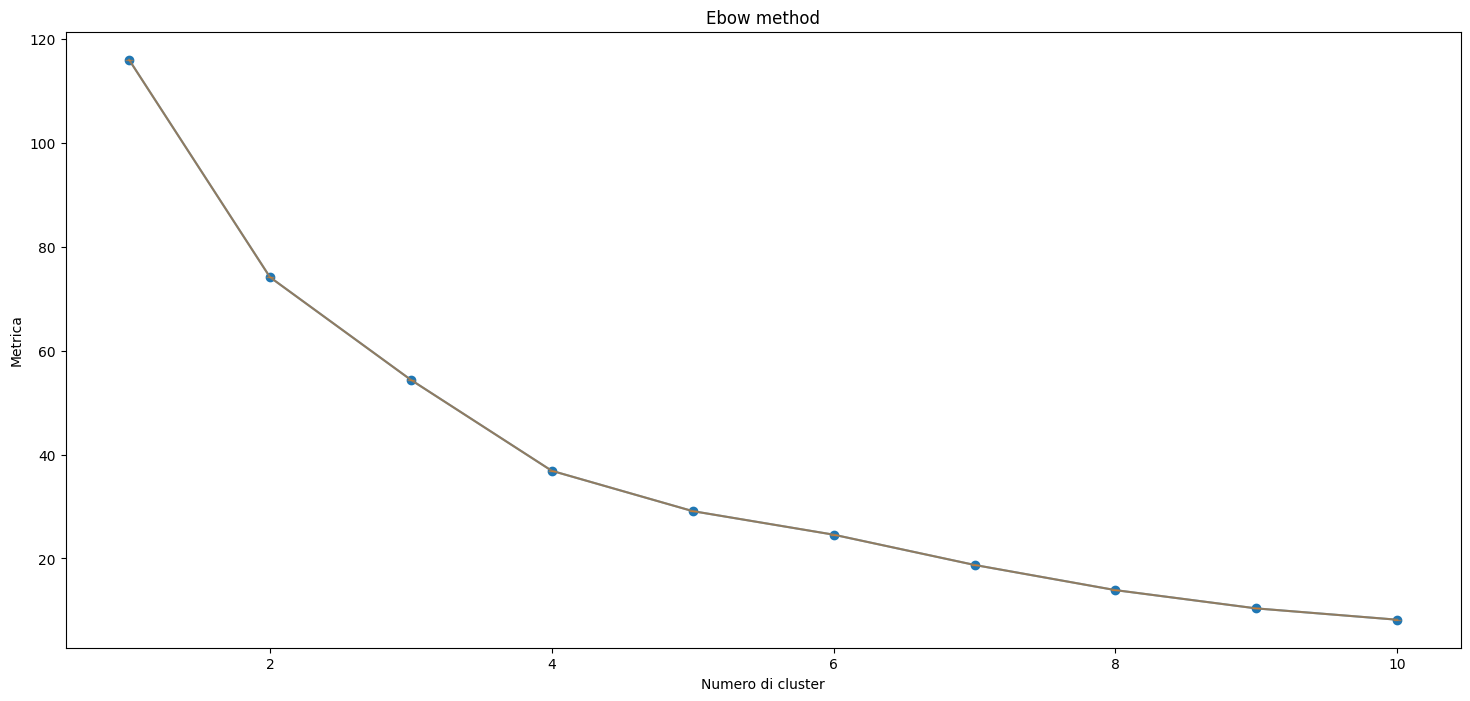

In [79]:
plt.figure(1, figsize=(18, 8))
plt.plot(np.arange(1,11), metrica, marker="o")
plt.plot(np.arange(1,11), metrica, marker="_", alpha=0.5)
plt.xlabel("Numero di cluster")
plt.ylabel("Metrica")
plt.title("Ebow method")
plt.show()

In [84]:
kmeans_cluster=KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=111, algorithm='elkan', tol=0.0001)
kmeans_cluster.fit(db_cluster)
labels=kmeans_cluster.labels_

Visualizzazione dell'assegnazione dei titoli ad ogni clsuter.

In [85]:
print((labels))

[0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 2 1]


Visualizzazione di come vengono assegnati i diversi titoli ad ogni cluster.

In [86]:
db_cluster["cluster"]=labels


In [87]:
db_cluster.head(30)

,Omega,Alpha,Beta,Nu,cluster
Ticker,,,,,
AAPL,0.900229,-1.313166,-1.192785,1.209390,0
ADBE,1.305543,1.328393,-1.068305,-0.676538,0
AMD,-0.754719,-0.752293,0.198143,-0.634895,1
AMZN,0.621150,0.529748,-0.495422,0.097384,0
BA,-0.192262,0.540743,-0.249678,-0.184445,0
BAC,-0.128198,0.097295,0.132126,0.315747,0
CAT,-0.126939,1.371271,-1.085069,-0.184898,0
CVX,-0.027334,0.551140,-0.261089,-0.624948,0
DE,0.096007,0.145100,0.128274,-0.334097,0


In [88]:
db_cluster_media=db_cluster.groupby("cluster").mean()
db_cluster_std=db_cluster.groupby("cluster").std()
print(db_cluster_media)
print(db_cluster_std)

            Omega     Alpha      Beta        Nu
cluster                                        
0        0.216476  0.526741 -0.609820  0.037643
1       -0.372064 -1.053100  1.212939 -0.539874
2       -0.980938 -1.056928  1.279954  4.105996
            Omega     Alpha      Beta        Nu
cluster                                        
0        1.070220  0.773535  0.494961  0.701044
1        0.715244  0.350686  0.503534  0.137606
2             NaN       NaN       NaN       NaN


Come notiamo dal codice sopra, i parametri medi per ogni cluster risultano influenzati dalla standardizzazione sugli stessi parametri, pertanto quest'ultimi vanno riportati su scala normale.

In [89]:
media_alpha=db_cluster['Alpha'].groupby(db_cluster['cluster']).mean()
media_omega=db_cluster['Omega'].groupby(db_cluster['cluster']).mean()
media_beta=db_cluster['Beta'].groupby(db_cluster['cluster']).mean()
pd_dataframe_media=pd.DataFrame({
    "Alpha": media_alpha,
    "Omega": media_omega,
    "Beta": media_beta
})
print(pd_dataframe_media)




            Alpha     Omega      Beta
cluster                              
0        0.526741  0.216476 -0.609820
1       -1.053100 -0.372064  1.212939
2       -1.056928 -0.980938  1.279954


In [90]:
def destandardizzazione(dati,media,std):
    parametri_scala_normale= (dati*std)+media
    return parametri_scala_normale


In [92]:
dataframe_kmeans_destandard=destandardizzazione(pd_dataframe_media,media_parametri,std_parametri)
print(dataframe_kmeans_destandard)

            Alpha      Beta  Nu     Omega
cluster                                  
0        0.656087  0.209560 NaN  0.002061
1        0.092736  0.864791 NaN  0.001050
2        0.091371  0.888880 NaN  0.000004


Dalla media destandardizzata dei parametri per ogni cluster vediamo come le condizioni di stazionarietà vengono rispettate. Il primo cluster presenta una reattività agli schock recenti molto elevata e persistente differentemente dagli ultimi due cluster che presentano una persistenza della volatilità nel tempo maggiore.

In [28]:
parametri_new=destandardizzazione(db_cluster,media_parametri,std_parametri)
print(parametri_new)

               Alpha          Beta          Nu         Omega  cluster
Ticker                                                               
AAPL    5.551115e-17  1.651840e-07  109.166664  3.236515e-03      NaN
ADBE    9.419454e-01  4.474699e-02    2.139192  3.933088e-03      NaN
AMD     1.999999e-01  4.999998e-01    4.502421  3.923152e-04      NaN
AMZN    6.571589e-01  2.506824e-01   46.059700  2.756888e-03      NaN
BA      6.610797e-01  3.390207e-01   30.065755  1.358955e-03      NaN
BAC     5.029521e-01  4.762684e-01   58.451945  1.469056e-03      NaN
CAT     9.572350e-01  3.872084e-02   30.040017  1.471220e-03      NaN
CVX     6.647872e-01  3.349187e-01    5.066945  1.642402e-03      NaN
DE      5.199987e-01  4.748839e-01   21.572872  1.854376e-03      NaN
GE      5.551115e-17  1.000000e+00   15.221607  2.404206e-03      NaN
GOOGL   5.551115e-17  1.000000e+00    2.050000  3.021444e-03      NaN
GS      6.088371e-01  3.866791e-01   95.959109  1.653329e-03      NaN
HD      5.955273e-04

In [93]:
db_parametri_cluster["labels"]=labels


Visualizzazione in 3D del posizionamento dei titoli in base ai parametri dei modelli Garch stimati.

In [94]:
import plotly.graph_objects as go

trace = go.Scatter3d(
    x=db_cluster['Omega'],
    y=db_cluster['Alpha'],
    z=db_cluster['Beta'],
    mode='markers',
    marker=dict(
        color=db_cluster['cluster'],  # label K-Means
        size=6,
        opacity=0.8
    )
)

fig = go.Figure(data=[trace])
fig.update_layout(
    title="Clusters (Omega, Alpha, Beta)",
    scene=dict(
        xaxis_title="Omega",
        yaxis_title="Alpha",
        zaxis_title="Beta"
    )
)
fig.show()

Confronto con un'altra metrica di agglomeritve clustering (Metodo Ward), che a differenza del precedente metodo punta a creare cluster omogenei fra loro e distaccati dagli altri cluster. Il calcolo della distanza si basa sulla misura di distanza euclidea e minimizza l'aumento della varianza interna quando vengono uniti due cluster.

I risultati del modello di clustering sono visualizzati attraverso un dendogramma, che rappresenta una visualizzazione grafica ad albero nel clustering gerarchico e non serve specificare a priori il numero di cluster.

In [32]:
from scipy.cluster.hierarchy import dendrogram

In [96]:
def plot_dendrogram(model, labels=None, **kwargs):
    """
    Plot dendrogram per AgglomerativeClustering con etichette ticker.

    Parameters:
    - model: fitted AgglomerativeClustering
    - labels: list of ticker (es. db_rendimenti.columns.tolist())
    - **kwargs: passed to dendrogram (es. truncate_mode, p)
    """
    # Conta campioni sotto ogni nodo
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    # Crea linkage matrix
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    # Plot dendrogramma con labels
    dendrogram(linkage_matrix, labels=labels, **kwargs)

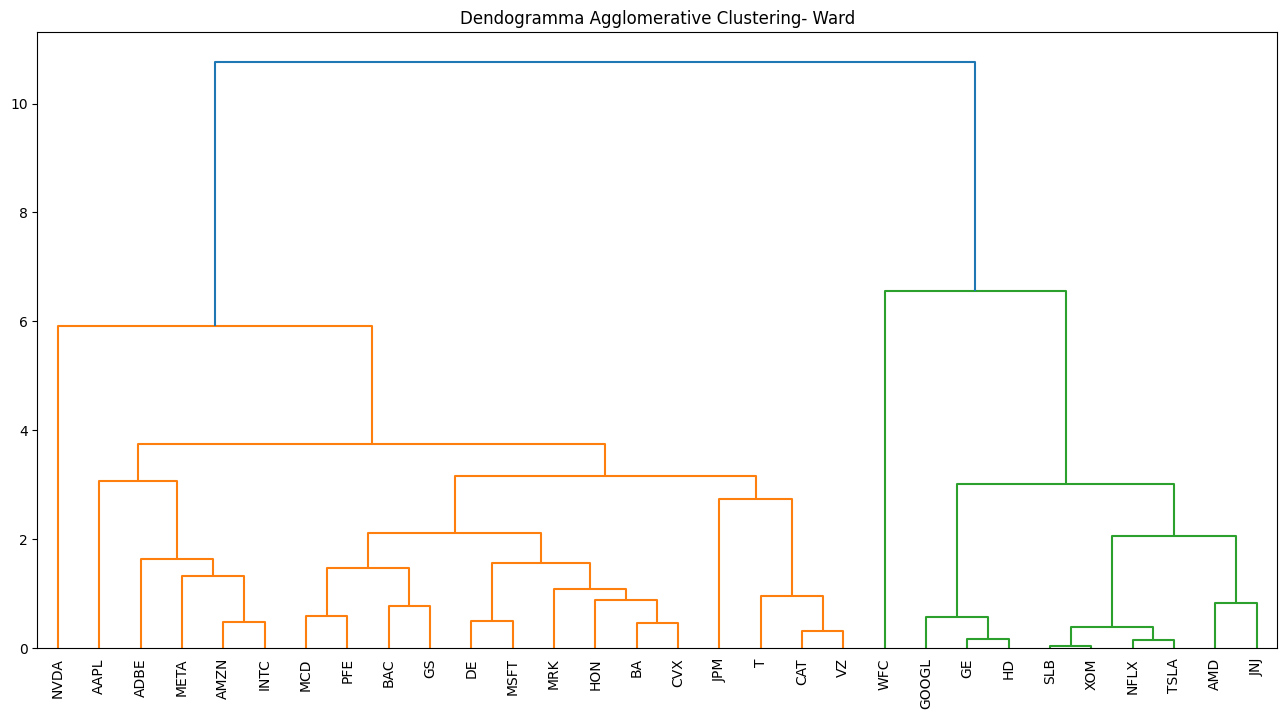

In [99]:
tick= rendimenti.columns
plt.figure(figsize=(16, 8))
plt.title("Dendogramma Agglomerative Clustering- Ward")
plot_dendrogram(clustering_ward,
                labels=tick,
                leaf_rotation=90,      # Ruota etichette di 90°
                leaf_font_size=10,
                         # Riduce dimensione font
)


Utilizziamo l'indice di silhouette per avere un secondo confronto per valutare il numero ottimale di cluster, tale indice medio restituisce i valori per numero di cluster che punta a massimizzare la distanza dagli altri cluster e minimizzare la distanza interna.
I risultati ottenuti mostrano come una specificazione di 6 cluster sarebbe ottimale per il suddetto modello di clustering.

k=2, silhouette=0.459
k=3, silhouette=0.463
k=4, silhouette=0.480
k=5, silhouette=0.333
k=6, silhouette=0.296
k=7, silhouette=0.306
k=8, silhouette=0.316
k=9, silhouette=0.325
k=10, silhouette=0.315
k=11, silhouette=0.352


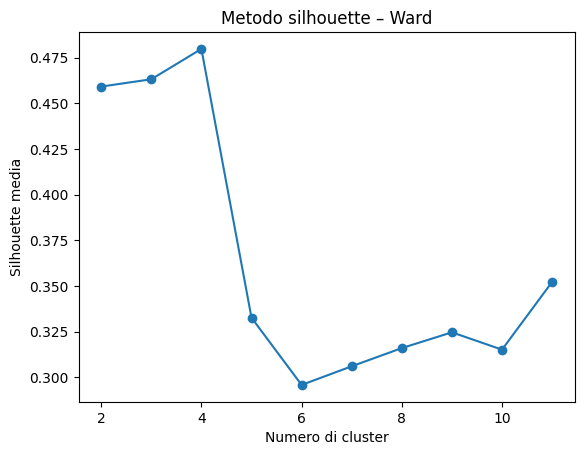

In [98]:
scores = []

for k in range(2, 12):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(db_cluster)
    score = silhouette_score(db_cluster, labels)
    scores.append(score)
    print(f"k={k}, silhouette={score:.3f}")

plt.figure()
plt.plot(range(2, 12), scores, marker='o')
plt.xlabel("Numero di cluster")
plt.ylabel("Silhouette media")
plt.title("Metodo silhouette – Ward")
plt.show()

In [103]:
clustering_ward=AgglomerativeClustering(n_clusters=3, linkage="ward", metric="euclidean",  compute_distances=True)
model=clustering_ward.fit(db_cluster)
labels_ward=clustering_ward.labels_


In [104]:
print(labels_ward)  # [0, 0, 1, 2, 0, ...]


[0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 2 1]


In [105]:
df_cluster = pd.DataFrame(db_cluster)  # Converte in DataFrame

# Aggiunge colonna labels
df_cluster['cluster'] = labels_ward

# Calcola medie per cluster e feature
medie_cluster = df_cluster.groupby('cluster').mean()
print(medie_cluster)

            Omega     Alpha      Beta        Nu  labels
cluster                                                
0        0.216476  0.526741 -0.609820  0.037643     0.0
1       -0.372064 -1.053100  1.212939 -0.539874     1.0
2       -0.980938 -1.056928  1.279954  4.105996     2.0


In [106]:
cluster_3_titoli = df_cluster[df_cluster['cluster'] == 3].index.tolist()
print(cluster_3_titoli)


[]


In [107]:
# Destandardizzazione dei parametri per conforntare le medie dei cluster ottenuti tramite algoritmo Ward

dataframe_standardizzato_ward=destandardizzazione(medie_cluster,media_parametri,std_parametri)

In [108]:
dataframe_standardizzato_ward.drop("labels",axis=1,)

,Alpha,Beta,Nu,Omega
cluster,,,,
0,0.656087,0.209560,42.669383,0.002061
1,0.092736,0.864791,9.894930,0.001050
2,0.091371,0.888880,273.550792,0.000004


Introduzione dell'algoritmo di clustering fuzzy-Kmeans che permette una classificazione soft con l'assegnazione del titolo ad ogni cluster con diverso grado di appartenenza, per adoperare un confronto più completo e senza forzare la suddivsione dei titoli.

In [29]:
pip install scikit-fuzzy

In [110]:
import skfuzzy as fuzz

Calcolo dell'indice di silhouette per un valore di fuzziness che appartiene ad un range(1.2-2.5), questo valore permette di specificare l'appartenza o meno ad un singolo cluster, maggiore è il valore del parametro m, più il titolo può avere un grado di assegnazione distribuito fra i diversi cluster. Seppure il valore di silhouette sia maggiore con m=1.2, si tende a preferire una suddivisione più bilanciata dei titoli nei seguenti cluster e quindi viene utilizzato un valore m=2, con un valore k=3 cluster.

FUZZY C-MEANS - Silhouette Scores:
k	|	m=1.2	m=1.5	m=2.0	m=2.5
----------------------------------------
2	|	0.4592	|	0.4592	|	0.4592	|	0.459
3	|	0.4683	|	0.4683	|	0.2773	|	0.277
4	|	0.4844	|	0.2534	|	0.2484	|	0.231
5	|	0.3145	|	0.3145	|	0.2115	|	0.225
6	|	0.3036	|	0.2926	|	0.2756	|	0.275
7	|	0.2577	|	0.2947	|	0.3127	|	0.281
8	|	0.3288	|	0.3508	|	0.2648	|	0.227


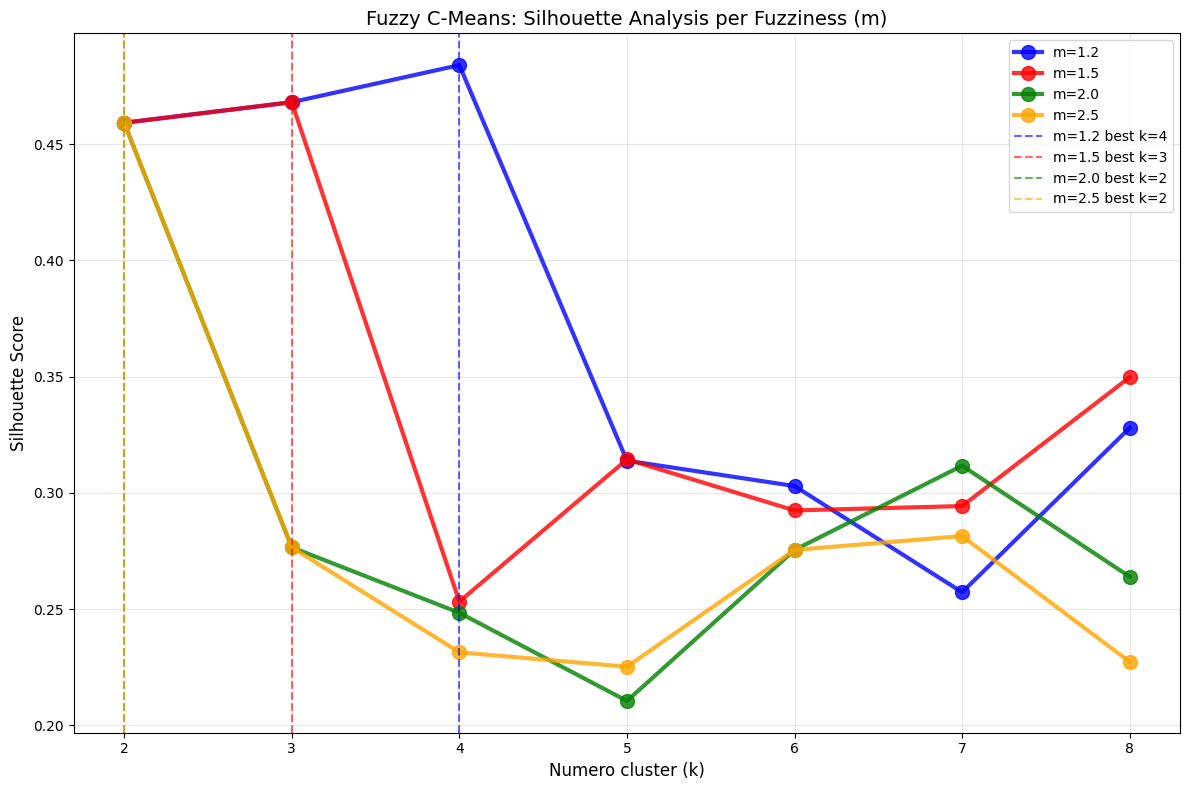


 RISULTATI COMPLETI:
   k  m=1.2  m=1.5  m=2.0  m=2.5
0  2  0.459  0.459  0.459  0.459
1  3  0.468  0.468  0.277  0.277
2  4  0.484  0.253  0.248  0.231
3  5  0.314  0.314  0.211  0.225
4  6  0.303  0.292  0.275  0.275
5  7  0.257  0.294  0.312  0.281
6  8  0.328  0.350  0.264  0.227

 CONFIGURAZIONI OTTIMALI:
m=1.2: k=4 (silhouette=0.484)
m=1.5: k=3 (silhouette=0.468)
m=2.0: k=2 (silhouette=0.459)
m=2.5: k=2 (silhouette=0.459)


In [111]:
# Range parametri
k_range = range(2, 9)  # Numero cluster
m_range = [1.2, 1.5, 2.0, 2.5]  # Fuzziness

# Dizionario per salvare scores
fuzzy_scores = {m: [] for m in m_range}

print("FUZZY C-MEANS - Silhouette Scores:")
print("k\t|\tm=1.2\tm=1.5\tm=2.0\tm=2.5")
print("-" * 40)

# Calcolo silhouette per ogni combinazione k-m
for k in k_range:
    row_scores = []
    for m in m_range:
        # Fuzzy C-Means
        cntr, u, u0, d, jm, p, fpc = fuzz.cmeans(
            db_cluster.T,
            c=k,
            m=m,
            error=0.005,
            maxiter=300
        )

        # Hard clustering per silhouette
        labels_hard = np.argmax(u, axis=0)

        # Silhouette score
        score = silhouette_score(db_cluster, labels_hard)
        fuzzy_scores[m].append(score)
        row_scores.append(score)

        print(f"{k}\t|\t{score:.3f}", end='')

    print()  # Nuova riga

# PLOT
plt.figure(figsize=(12, 8))

# Singole linee per ogni m
colors = ['blue', 'red', 'green', 'orange']
for i, m in enumerate(m_range):
    plt.plot(k_range, fuzzy_scores[m], 'o-',
             linewidth=3, markersize=10,
             label=f'm={m}',
             color=colors[i],
             alpha=0.8)

# Miglior k per ogni m
for i, m in enumerate(m_range):
    best_k = np.argmax(fuzzy_scores[m]) + 2
    plt.axvline(x=best_k, color=colors[i], linestyle='--', alpha=0.6,
                label=f'm={m} best k={best_k}')

plt.xlabel('Numero cluster (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Fuzzy C-Means: Silhouette Analysis per Fuzziness (m)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# TABELLla riassuntiva
df_results = pd.DataFrame({
    'k': list(k_range),
    'm=1.2': fuzzy_scores[1.2],
    'm=1.5': fuzzy_scores[1.5],
    'm=2.0': fuzzy_scores[2.0],
    'm=2.5': fuzzy_scores[2.5]
})

print("\n RISULTATI COMPLETI:")
print(df_results.round(3))

# Migliori configurazioni
print("\n CONFIGURAZIONI OTTIMALI:")
for m in m_range:
    best_k_idx = np.argmax(fuzzy_scores[m])
    best_k = best_k_idx + 2
    best_score = fuzzy_scores[m][best_k_idx]
    print(f"m={m}: k={best_k} (silhouette={best_score:.3f})")


Visualizzazione del metodo Fuzzy-kmeans, attraverso l'assegnazione soft di ogni titolo ad un cluster; per renderlo comparabile utilizziamo la funzione argmax in modo da ottenere il valore unitario per il cluster con assegnazione maggiore.

In [112]:
cntr, u, _, _, _, _, fpc = fuzz.cmeans(db_cluster.T, c=3, m=1.5, error=0.005, maxiter=300)


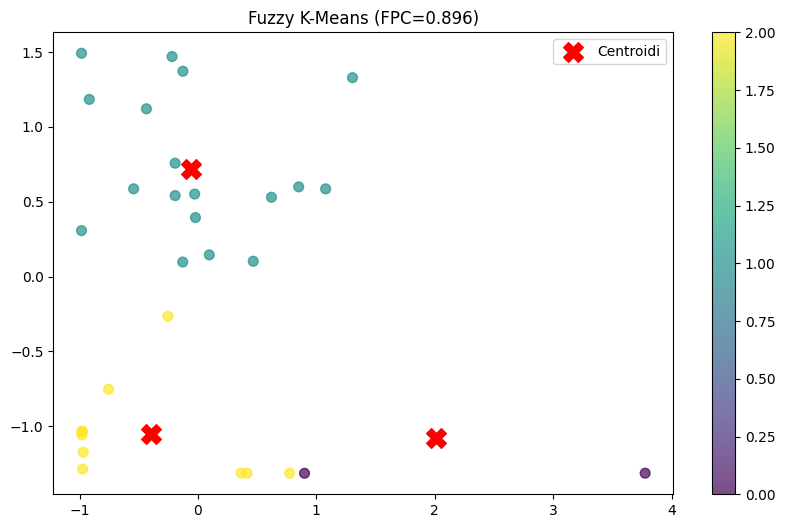

In [113]:

partition_hard = np.argmax(u, axis=0)

plt.figure(figsize=(10,6))
scatter = plt.scatter(db_cluster.iloc[:,0], db_cluster.iloc[:,1],
                     c=partition_hard, cmap='viridis', s=50, alpha=0.7)
plt.scatter(cntr[:,0], cntr[:,1], c='red', s=200, marker='X', label='Centroidi')
plt.colorbar(scatter)
plt.title(f'Fuzzy K-Means (FPC={fpc:.3f})')
plt.legend()
plt.show()


L'ulteriore analisi conferma che la partizione che si avvicina a suddividere in modo più corretto i titoli utilizza 3 cluster. Il valore fpc (fuzzy partition coefficient) rappresenta il grado di partizione da soft ad hard nei vari cluster. Il valore ottenuto è un buon indicatore di partizionamento dei titoli.

In [115]:
# Dopo cmeans()
n_clusters_real = u.shape[0]
partition_hard = np.argmax(u, axis=0)

# DataFrame dinamico
df_memberships = pd.DataFrame(
    u.T,
    columns=[f'Cluster_{i}' for i in range(n_clusters_real)]
)
df_memberships['Hard_Cluster'] = partition_hard

print("Shape OK:", df_memberships.shape)
print(df_memberships.head())


Shape OK: (30, 4)
   Cluster_0  Cluster_1  Cluster_2  Hard_Cluster
0   0.921645   0.059011   0.019344             0
1   0.123285   0.847107   0.029608             1
2   0.011035   0.055109   0.933856             2
3   0.009951   0.986789   0.003260             1
4   0.000353   0.999088   0.000559             1


In [116]:
# Dopo: df_memberships con Cluster_0...Cluster_5 e Hard_Cluster

# 1. Calcola Max Membership per ogni titolo
df_memberships['Max_Membership'] = df_memberships[[f'Cluster_{i}' for i in range(3)]].max(axis=1)

# 2. STATISTICHE riassuntive (la tua Tabella 5.12)
print("Tabella 5.12. Sintesi dei gradi di appartenenza massimi nel fuzzy K-means")
print("="*70)

stats = {
    'Max membership media': df_memberships['Max_Membership'].mean().round(3),
    'Numero titoli > 0.8': (df_memberships['Max_Membership'] > 0.8).sum(),
    'Numero titoli < 0.6': (df_memberships['Max_Membership'] < 0.6).sum()
}

for key, value in stats.items():
    print(f"{key}: {value}")

# 3. Tabella completa (come tesi/relazione)
tabella_512 = pd.DataFrame({
    'Statistica': list(stats.keys()),
    'Valore': list(stats.values())
})
print("\n", tabella_512)


Tabella 5.12. Sintesi dei gradi di appartenenza massimi nel fuzzy K-means
Max membership media: 0.937
Numero titoli > 0.8: 28
Numero titoli < 0.6: 1

              Statistica  Valore
0  Max membership media   0.937
1   Numero titoli > 0.8  28.000
2   Numero titoli < 0.6   1.000


In [117]:
# Assumendo:
# - db_parametri_cluster = DataFrame (righe=titoli, colonne=['Omega','Alpha','Beta','Nu'])
# - df_cluster['cluster'] = labels_ward (hard clustering)
# - ticker_list = lista ticker nell'ordine di db_cluster

# 1. Mappa ticker → cluster
df_parametri_con_cluster = db_parametri_cluster.copy()
df_parametri_con_cluster['cluster'] = df_cluster['cluster'].values  # Allinea ordine!

# 2. Calcola MEDIE GARCH per cluster
parametri_cluster = df_parametri_con_cluster.groupby('cluster')[['Omega','Alpha','Beta','Nu']].mean()
print("PARAMETRI GARCH MEDI per CLUSTER:")
print(parametri_cluster.round(6))

# 3. Lista TITOLI per cluster + loro parametri
for c in range(3):
    titoli_cluster = df_parametri_con_cluster[df_parametri_con_cluster['cluster']==c].index
    print(f"\nCluster {c} ({len(titoli_cluster)} titoli):")
    print(titoli_cluster.tolist())
    print(df_parametri_con_cluster[df_parametri_con_cluster['cluster']==c][['Omega','Alpha','Beta','Nu']].round(4))


PARAMETRI GARCH MEDI per CLUSTER:
            Omega     Alpha      Beta        Nu
cluster                                        
0        0.216476  0.526741 -0.609820  0.037643
1       -0.372064 -1.053100  1.212939 -0.539874
2       -0.980938 -1.056928  1.279954  4.105996

Cluster 0 (20 titoli):
['AAPL', 'ADBE', 'AMZN', 'BA', 'BAC', 'CAT', 'CVX', 'DE', 'GS', 'HON', 'INTC', 'JPM', 'MCD', 'META', 'MRK', 'MSFT', 'NVDA', 'PFE', 'T', 'VZ']
         Omega   Alpha    Beta      Nu
Ticker                                
AAPL    0.9002 -1.3132 -1.1928  1.2094
ADBE    1.3055  1.3284 -1.0683 -0.6765
AMZN    0.6211  0.5297 -0.4954  0.0974
BA     -0.1923  0.5407 -0.2497 -0.1844
BAC    -0.1282  0.0973  0.1321  0.3157
CAT    -0.1269  1.3713 -1.0851 -0.1849
CVX    -0.0273  0.5511 -0.2611 -0.6249
DE      0.0960  0.1451  0.1283 -0.3341
GS     -0.0210  0.3942 -0.1171  0.9767
HON    -0.5428  0.5862 -0.8882 -0.4189
INTC    0.8512  0.5992 -0.6128 -0.2946
JPM    -0.9175  1.1832 -0.8872  1.7898
MCD    -0.1927

Dopo la valutazione col metodo soft, abbiamo una buona suddivisione dei titoli con la metà che mostrano un valore di 28 titoli con valore maggiore di 0.8, e solo un titolo con valore minore di 0.6.